# 🤖 Modelado — Student Depression

**Objetivo:** entrenar y comparar modelos de **clasificación** para predecir el riesgo de depresión (`Depression`), y evaluar el mejor con métricas apropiadas.

**Flujo:**
1. Carga y separación X / y
2. Split entrenamiento / prueba (estratificado)
3. Comparación de modelos por validación cruzada
4. Evaluación del mejor modelo en el conjunto de prueba
5. Importancia de variables

> ⚠️ **Nota ética:** el modelo es una herramienta de análisis estadístico, **no** un diagnóstico clínico. En un problema de salud mental el **recall** de la clase positiva es especialmente importante (evitar falsos negativos).

## 1. Configuración

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import RocCurveDisplay

from src.data.loaders import load_raw_data
from src.features.engineering import split_X_y
from src.models.train import get_models, build_pipeline, evaluate
from src.config.constants import RANDOM_STATE, TARGET

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
print("Setup listo ✅")

Setup listo ✅


## 2. Carga y separación de X / y

In [2]:
df = load_raw_data()
X, y = split_X_y(df)
print(f"X: {X.shape}  |  y: {y.shape}")
print(f"Distribución del objetivo:\n{y.value_counts(normalize=True).round(3)}")

X: (27901, 16)  |  y: (27901,)
Distribución del objetivo:
Depression
1    0.585
0    0.415
Name: proportion, dtype: float64


## 3. Split entrenamiento / prueba

Usamos un split **estratificado** (80/20) para conservar la proporción de clases.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")

Train: 22,320  |  Test: 5,581


## 4. Comparación de modelos (validación cruzada)

Comparamos Logistic Regression, Decision Tree y Random Forest con validación cruzada
estratificada de 5 folds, usando **F1** como métrica principal.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, model in get_models().items():
    pipe = build_pipeline(model)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    results.append({"modelo": name, "f1_mean": scores.mean(), "f1_std": scores.std()})
    print(f"{name:22s}  F1 = {scores.mean():.4f} ± {scores.std():.4f}")

results_df = pd.DataFrame(results).sort_values("f1_mean", ascending=False).reset_index(drop=True)
results_df

Logistic Regression     F1 = 0.8727 ± 0.0017


Decision Tree           F1 = 0.8537 ± 0.0021


Random Forest           F1 = 0.8671 ± 0.0011


,modelo,f1_mean,f1_std
0,Logistic Regression,0.872665,0.001750
1,Random Forest,0.867073,0.001078
2,Decision Tree,0.853694,0.002102


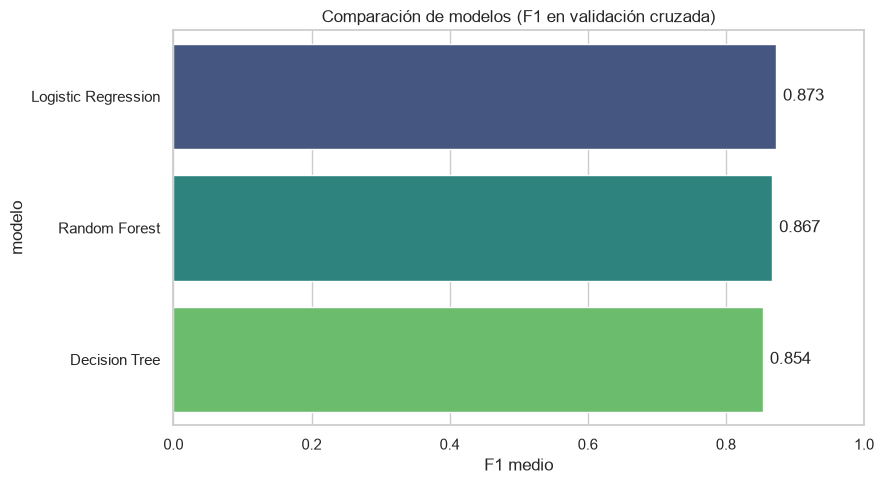

In [5]:
ax = sns.barplot(data=results_df, x="f1_mean", y="modelo", hue="modelo", legend=False, palette="viridis")
ax.set_title("Comparación de modelos (F1 en validación cruzada)")
ax.set_xlabel("F1 medio")
ax.set_xlim(0, 1)
for i, row in results_df.iterrows():
    ax.text(row["f1_mean"] + 0.01, i, f"{row['f1_mean']:.3f}", va="center")
plt.tight_layout()
plt.show()

## 5. Entrenamiento y evaluación del mejor modelo

Tomamos el modelo con mejor F1 en validación cruzada, lo entrenamos con todo el train
y lo evaluamos sobre el conjunto de prueba (nunca visto).

In [6]:
best_name = results_df.iloc[0]["modelo"]
print(f"Mejor modelo: {best_name}")

best_pipe = build_pipeline(get_models()[best_name])
best_pipe.fit(X_train, y_train)

metrics = evaluate(best_pipe, X_test, y_test)
print(f"\nAccuracy : {metrics['accuracy']:.4f}")
print(f"F1       : {metrics['f1']:.4f}")
print(f"ROC-AUC  : {metrics['roc_auc']:.4f}")
print(f"\nReporte de clasificación:\n{metrics['report']}")

Mejor modelo: Logistic Regression



Accuracy : 0.8436
F1       : 0.8681
ROC-AUC  : 0.9184

Reporte de clasificación:
              precision    recall  f1-score   support

           0      0.823     0.794     0.808      2313
           1      0.858     0.879     0.868      3268

    accuracy                          0.844      5581
   macro avg      0.840     0.836     0.838      5581
weighted avg      0.843     0.844     0.843      5581



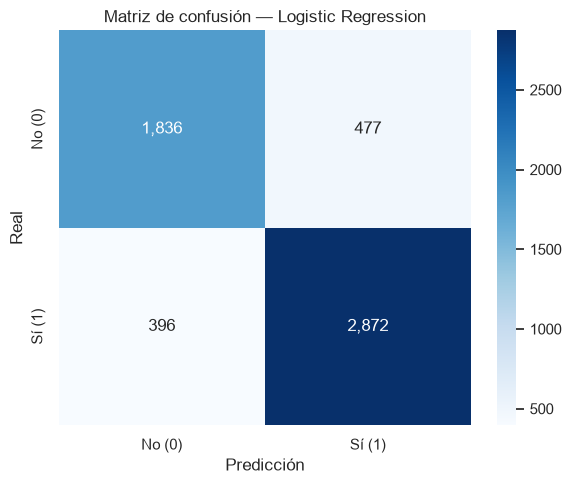

In [7]:
# Matriz de confusión
cm = metrics["confusion_matrix"]
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues",
            xticklabels=["No (0)", "Sí (1)"], yticklabels=["No (0)", "Sí (1)"])
plt.title(f"Matriz de confusión — {best_name}")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

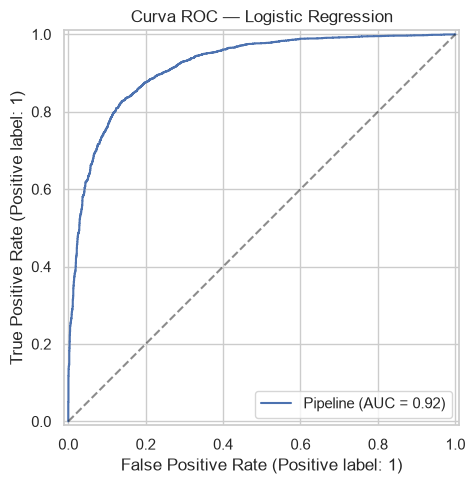

In [8]:
# Curva ROC
RocCurveDisplay.from_estimator(best_pipe, X_test, y_test)
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.title(f"Curva ROC — {best_name}")
plt.tight_layout()
plt.show()

## 6. Importancia de variables

Extraemos las variables más influyentes según el modelo entrenado (coeficientes para
Logistic Regression, importancias para modelos de árbol).

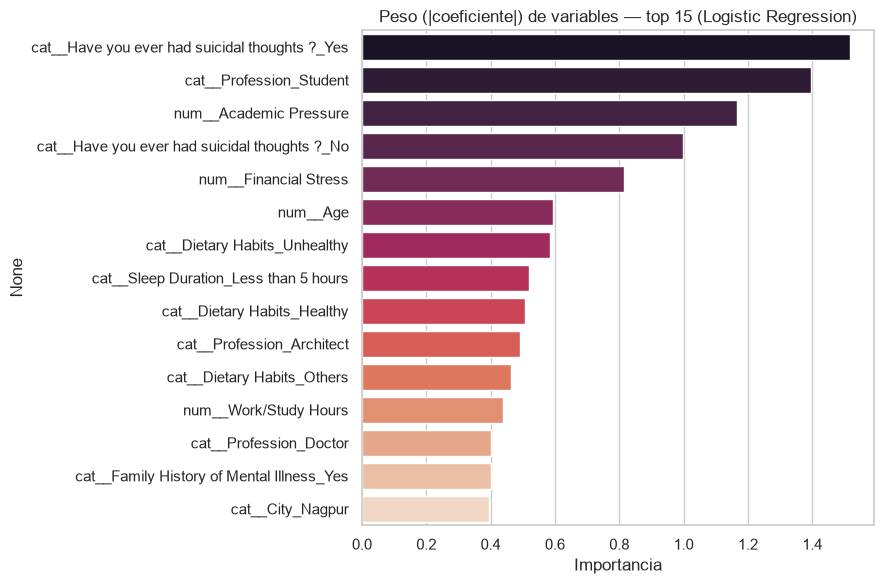

cat__Have you ever had suicidal thoughts ?_Yes    1.516200
cat__Profession_Student                           1.395688
num__Academic Pressure                            1.165678
cat__Have you ever had suicidal thoughts ?_No     0.997609
num__Financial Stress                             0.813829
num__Age                                          0.594981
cat__Dietary Habits_Unhealthy                     0.583184
cat__Sleep Duration_Less than 5 hours             0.518313
cat__Dietary Habits_Healthy                       0.506441
cat__Profession_Architect                         0.492758
cat__Dietary Habits_Others                        0.463738
num__Work/Study Hours                             0.439167
cat__Profession_Doctor                            0.402326
cat__Family History of Mental Illness_Yes         0.400258
cat__City_Nagpur                                  0.394589
dtype: float64

In [9]:
# Nombres de las variables tras el preprocesamiento (One-Hot incluido)
feature_names = best_pipe.named_steps["preprocessor"].get_feature_names_out()
model = best_pipe.named_steps["model"]

if hasattr(model, "feature_importances_"):
    importances = model.feature_importances_
    title = "Importancia de variables"
elif hasattr(model, "coef_"):
    importances = np.abs(model.coef_[0])
    title = "Peso (|coeficiente|) de variables"
else:
    importances = None

if importances is not None:
    imp = (pd.Series(importances, index=feature_names)
           .sort_values(ascending=False).head(15))
    plt.figure(figsize=(9, 6))
    sns.barplot(x=imp.values, y=imp.index, hue=imp.index, legend=False, palette="rocket")
    plt.title(f"{title} — top 15 ({best_name})")
    plt.xlabel("Importancia")
    plt.tight_layout()
    plt.show()
    display(imp)

## 7. Guardar el modelo entrenado

Persistimos el pipeline completo (preprocesador + modelo) para reutilizarlo.

In [10]:
import joblib
from src.config.constants import MODELS_DIR

MODELS_DIR.mkdir(exist_ok=True)
model_path = MODELS_DIR / "best_pipeline.joblib"
joblib.dump(best_pipe, model_path)
print(f"Modelo guardado en: {model_path}")

Modelo guardado en: C:\student-depression-mlops\models\best_pipeline.joblib


## 8. Conclusiones

_Completa con los resultados obtenidos:_

- **Mejor modelo y desempeño:** indica accuracy, F1 y ROC-AUC en el conjunto de prueba.
- **Errores del modelo:** analiza la matriz de confusión — ¿hay muchos falsos negativos? (críticos en salud mental).
- **Variables clave:** las de mayor importancia suelen ser antecedentes de pensamientos suicidas, presión académica y estrés financiero.
- **Limitaciones:** el dataset es autoinformado; correlación ≠ causalidad; el modelo no reemplaza una evaluación profesional.
- **Siguientes pasos:** ajuste de hiperparámetros (GridSearch), manejo de umbral de decisión orientado a recall, y seguimiento de experimentos (MLflow) si se lleva a MLOps.